In [1]:
import Cosmo_util_data as cu
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import griddata, RectBivariateSpline
import random

# Base Code

La idea es hacer una interpolacion en k por cada z. Por cada z hay una misma lista de k ordenados de menor a mayor

**Interpolation**

In [2]:
path = 'pkz-Fiducial.txt'
data = np.loadtxt(path)

z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

# Se revisa que los k sean iguales para todos los z
k_all = data[:,1]
l = len(k_vals)

#print(len(z_vals)-1)

for i in range(0, len(z_vals)-1): # va de 0 a len(z_vals)-2
    l = len(k_vals)
    A = k_all[i*l : l*(i+1)]
    B = k_all[(i+1)*l : l*(i+2)]
    if not np.array_equal(A, B):
        print("Los arrays no son iguales, se detiene el for")
        break

P_new = []

for i, z in enumerate(z_vals):
    A = P_vals[i*l : l*(i+1)]
    #print(np.flip(A))
    #print(k_vals)
    P_new.append(list(np.flip(A))) # tengo que voltear P para alinearlo luego con el orden de k_vals (de menor a mayor)
    
P_inter = RectBivariateSpline(z_vals, np.log(k_vals), np.log(P_new))

**Check interpolation**

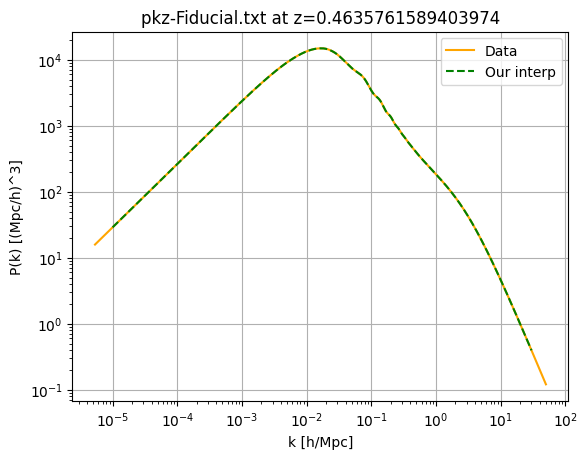

In [3]:
data = np.loadtxt(path)

z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

k_list = np.logspace(np.log10(0.00001), np.log10(30), 700) # va de 0.00001 a 30 en espacios logaritmicos
i = random.randint(0, 303) 
z = z_vals[i]
l = len(k_vals)


P_kk = P_inter
P_kk_evaluated = np.exp(P_kk(z, np.log(k_list)))

plt.plot(k_vals, np.flip(P_vals[l*(i): l*(i+1)]), '-', color = 'orange', label = 'Data')
plt.plot(k_list, P_kk_evaluated[0,:], '--', color = 'green', label = 'Our interp')
plt.xscale('log')
plt.yscale('log')   
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')#
plt.title(path + ' at z=' + str(z))
plt.grid()
plt.legend()
plt.show()

# Creando una función única

In [4]:
def interpolation(path, lineal = False):
    if lineal:
        idx_p = 2
    else:
        idx_p = 3
    data = np.loadtxt(path)

    z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
    k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
    P_vals = np.flip(data[:,idx_p]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

    # Se revisa que los k sean iguales para todos los z
    k_all = data[:,1]
    l = len(k_vals)

    #print(len(z_vals)-1)

    for i in range(0, len(z_vals)-1): # va de 0 a len(z_vals)-2
        l = len(k_vals)
        A = k_all[i*l : l*(i+1)]
        B = k_all[(i+1)*l : l*(i+2)]
        if not np.array_equal(A, B):
            print("Los arrays no son iguales, se detiene el for")
            break

    P_new = []

    for i, z in enumerate(z_vals):
        A = P_vals[i*l : l*(i+1)]
        #print(np.flip(A))
        #print(k_vals)
        P_new.append(list(np.flip(A))) # tengo que voltear P para alinearlo luego con el orden de k_vals (de menor a mayor)
    
    P_inter = RectBivariateSpline(z_vals, np.log(k_vals), np.log(P_new))
    return P_inter

In [5]:
def check_interpolation(path):
    data = np.loadtxt(path)
    
    z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
    k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
    P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

    k_list = np.logspace(np.log10(0.00001), np.log10(30), 700) # va de 0.00001 a 30 en espacios logaritmicos
    i = random.randint(0, 303) 
    z = z_vals[i]
    l = len(k_vals)


    P_kk = interpolation(path)
    P_kk_evaluated = np.exp(P_kk(z, np.log(k_list)))

    plt.plot(k_vals, np.flip(P_vals[l*(i): l*(i+1)]), '-', color = 'orange', label = 'Data')
    plt.plot(k_list, P_kk_evaluated[0,:], '--', color = 'green', label = 'Our interp')
    plt.xscale('log')
    plt.yscale('log')   
    plt.xlabel('k [h/Mpc]')
    plt.ylabel('P(k) [(Mpc/h)^3]')#
    plt.title(path + ' at z=' + str(z))
    plt.grid()
    plt.legend()
    plt.show()

In [6]:
datas = ['pkz-Fiducial.txt', 'pkz-Om_pl_eps_1p3E-2.txt', 'pkz-Om_mn_eps_1p3E-2.txt', 
         'pkz-s8_pl_eps_1p3E-2.txt', 'pkz-s8_mn_eps_1p3E-2.txt', 'pkz-h_pl_eps_1p3E-2.txt', 'pkz-h_mn_eps_1p3E-2.txt', 
         'pkz-ns_pl_eps_1p3E-2.txt', 'pkz-ns_mn_eps_1p3E-2.txt', 'pkz-Ob_pl_eps_1p3E-2.txt', 'pkz-Ob_mn_eps_1p3E-2.txt']

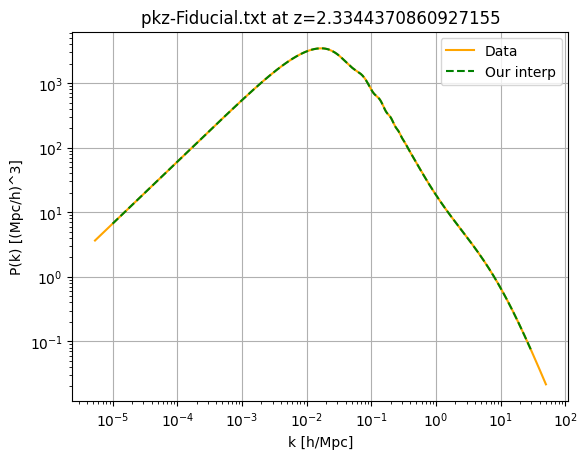

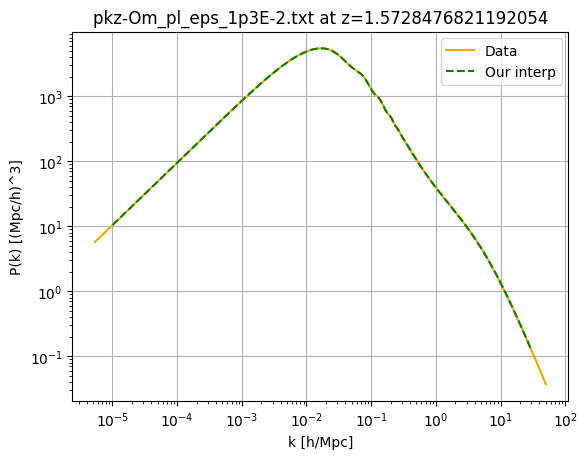

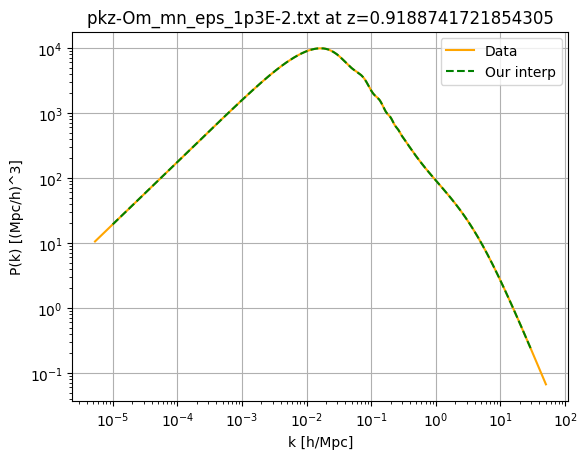

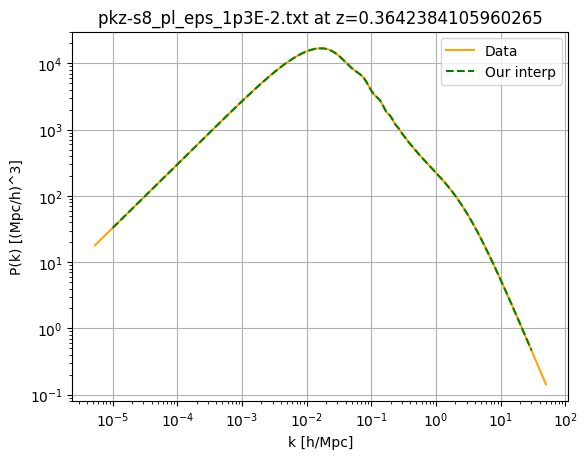

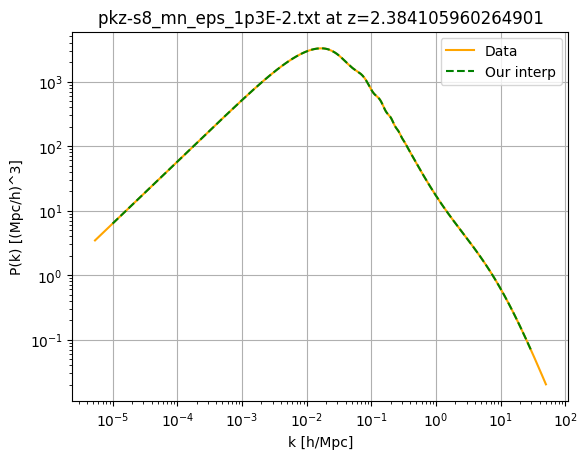

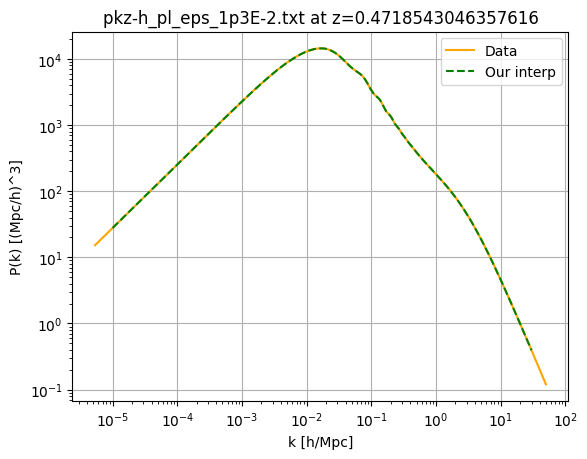

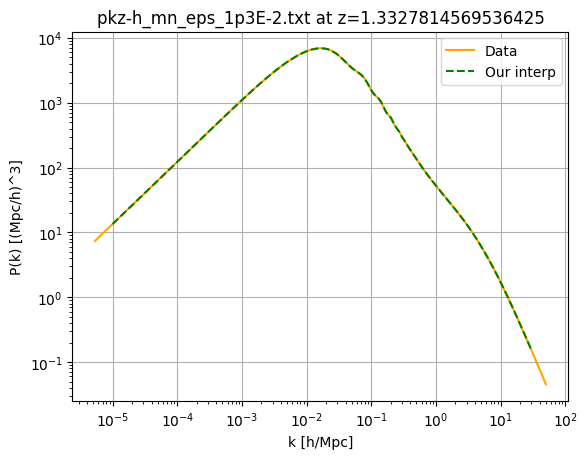

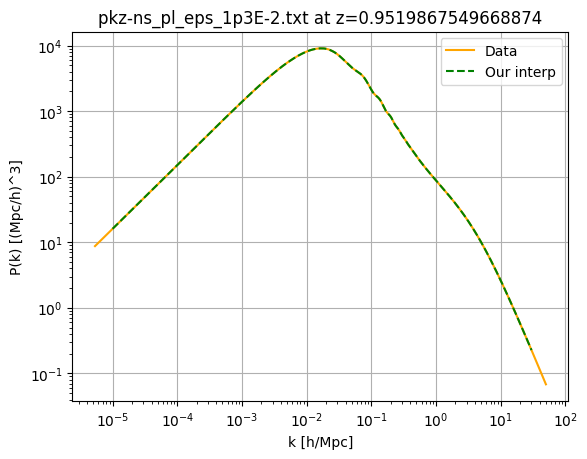

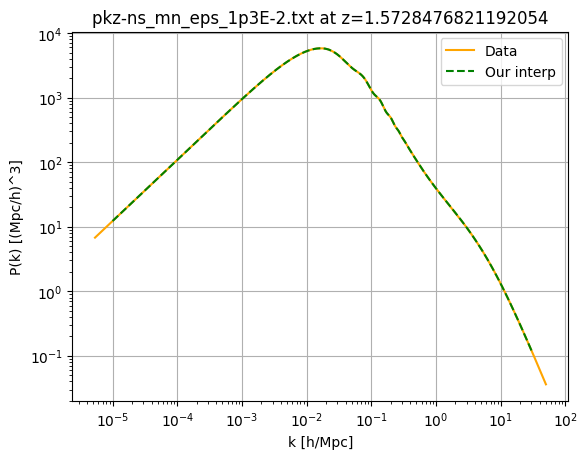

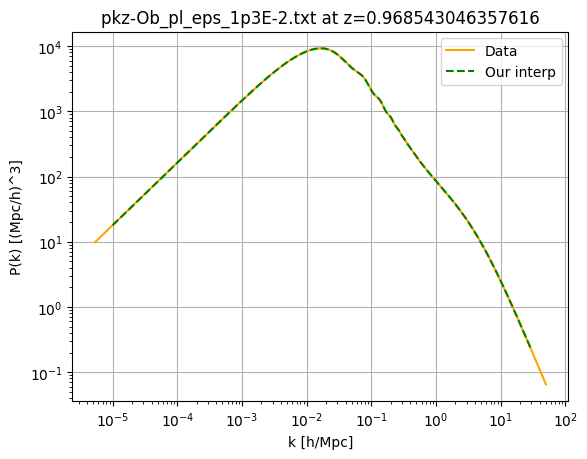

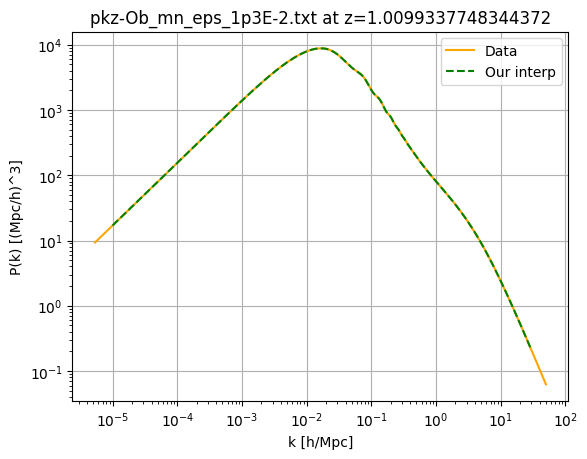

In [7]:
for data in datas:
    check_interpolation(data)

# Probing Interpolation.py

In [8]:
import Interpolation as int

In [9]:
datas = ['pkz-Fiducial.txt', 'pkz-Om_pl_eps_1p3E-2.txt', 'pkz-Om_mn_eps_1p3E-2.txt', 
         'pkz-s8_pl_eps_1p3E-2.txt', 'pkz-s8_mn_eps_1p3E-2.txt', 'pkz-h_pl_eps_1p3E-2.txt', 'pkz-h_mn_eps_1p3E-2.txt', 
         'pkz-ns_pl_eps_1p3E-2.txt', 'pkz-ns_mn_eps_1p3E-2.txt', 'pkz-Ob_pl_eps_1p3E-2.txt', 'pkz-Ob_mn_eps_1p3E-2.txt']

In [10]:
names = ['P_kk', 'Om_pl', 'Om_mn', 's8_pl', 's8_mn', 'h_pl', 'h_mn', 'ns_pl', 'ns_mn', 'Ob_pl', 'Ob_mn']

Interpolation of pkz-Fiducial.txt done
Interpolation of pkz-Fiducial.txt done


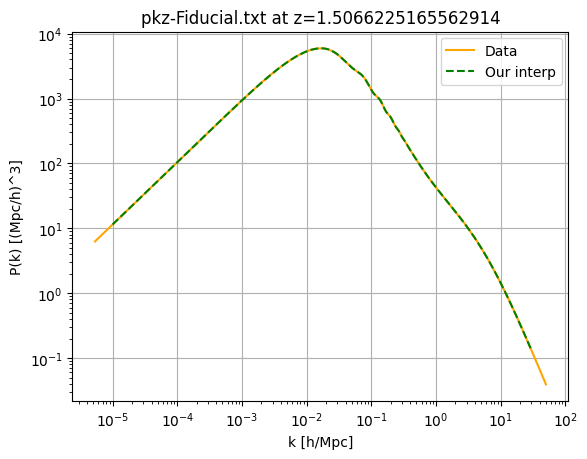

Interpolation of pkz-Om_pl_eps_1p3E-2.txt done
Interpolation of pkz-Om_pl_eps_1p3E-2.txt done


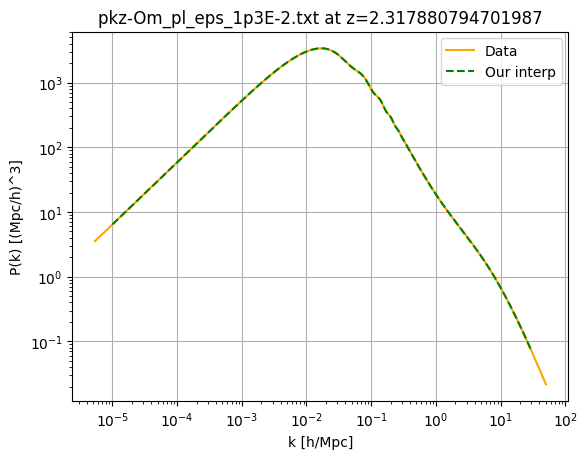

Interpolation of pkz-Om_mn_eps_1p3E-2.txt done
Interpolation of pkz-Om_mn_eps_1p3E-2.txt done


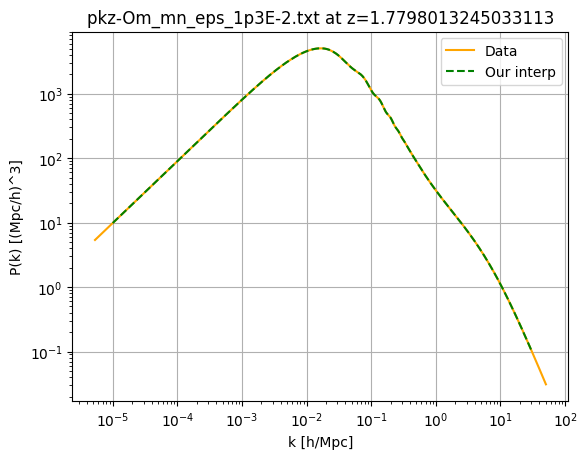

Interpolation of pkz-s8_pl_eps_1p3E-2.txt done
Interpolation of pkz-s8_pl_eps_1p3E-2.txt done


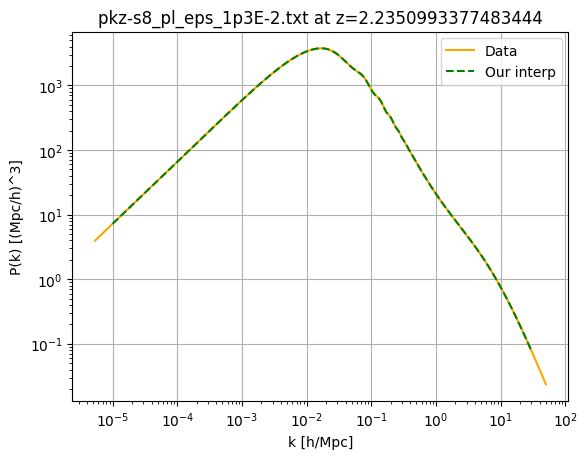

Interpolation of pkz-s8_mn_eps_1p3E-2.txt done
Interpolation of pkz-s8_mn_eps_1p3E-2.txt done


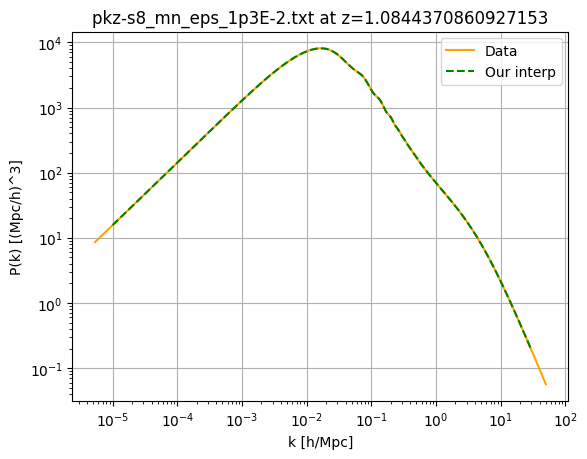

Interpolation of pkz-h_pl_eps_1p3E-2.txt done
Interpolation of pkz-h_pl_eps_1p3E-2.txt done


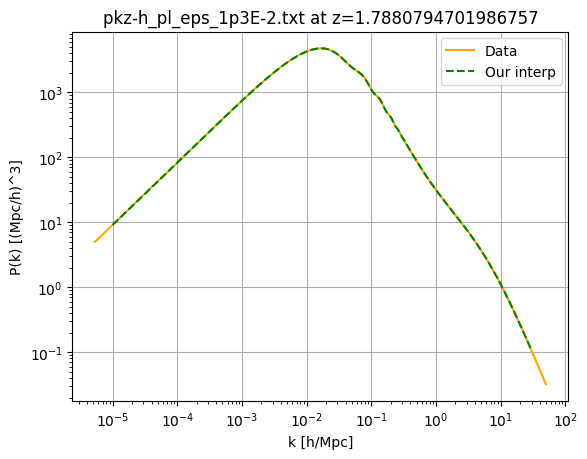

Interpolation of pkz-h_mn_eps_1p3E-2.txt done
Interpolation of pkz-h_mn_eps_1p3E-2.txt done


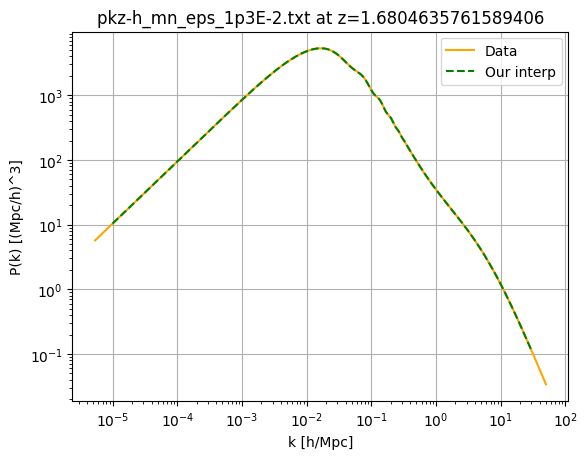

Interpolation of pkz-ns_pl_eps_1p3E-2.txt done
Interpolation of pkz-ns_pl_eps_1p3E-2.txt done


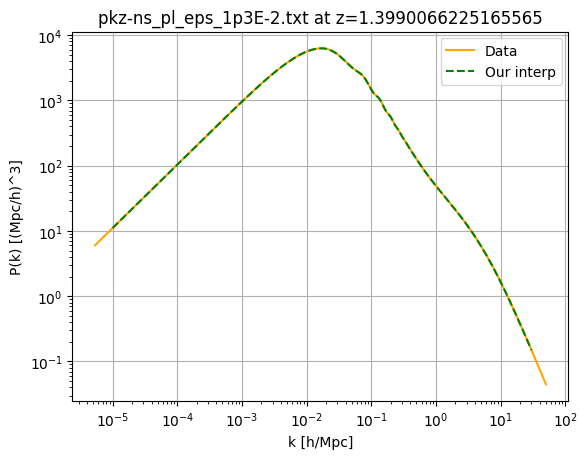

Interpolation of pkz-ns_mn_eps_1p3E-2.txt done
Interpolation of pkz-ns_mn_eps_1p3E-2.txt done


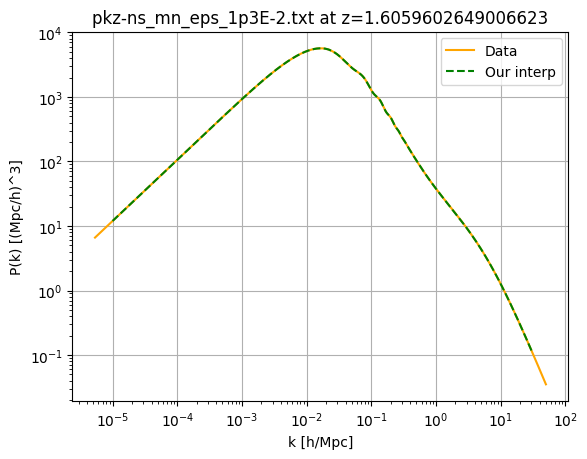

Interpolation of pkz-Ob_pl_eps_1p3E-2.txt done
Interpolation of pkz-Ob_pl_eps_1p3E-2.txt done


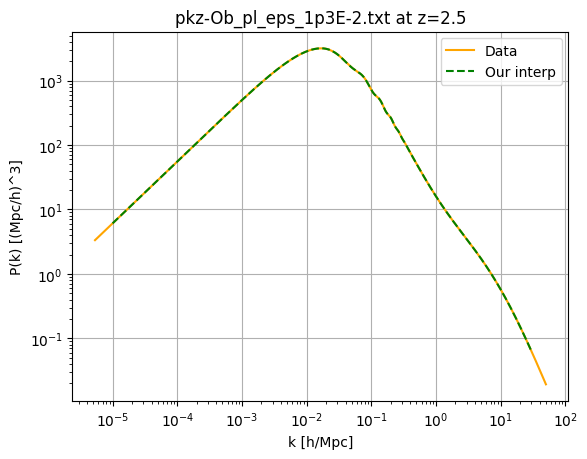

Interpolation of pkz-Ob_mn_eps_1p3E-2.txt done
Interpolation of pkz-Ob_mn_eps_1p3E-2.txt done


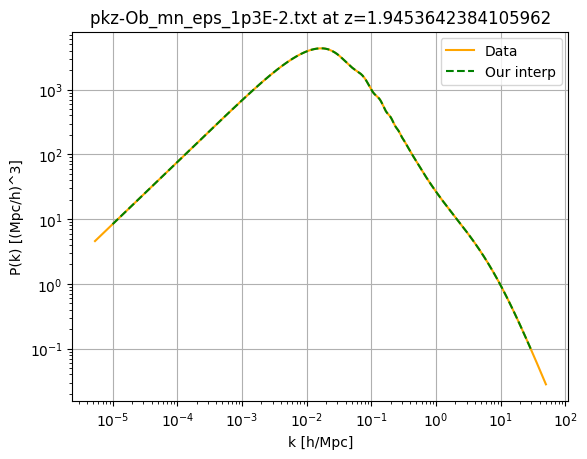

In [11]:
for i, name in enumerate(names):
    name = int.interpolation(datas[i])
    int.check_interpolation(datas[i])

# dP/dk

In [12]:
path = 'pkz-Fiducial.txt'
data = np.loadtxt(path)

z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

# Se revisa que los k sean iguales para todos los z
k_all = data[:,1]
l = len(k_vals)

#print(len(z_vals)-1)

for i in range(0, len(z_vals)-1): # va de 0 a len(z_vals)-2
    l = len(k_vals)
    A = k_all[i*l : l*(i+1)]
    B = k_all[(i+1)*l : l*(i+2)]
    if not np.array_equal(A, B):
        print("Los arrays no son iguales, se detiene el for")
        break

P_new = []

for i, z in enumerate(z_vals):
    A = P_vals[i*l : l*(i+1)]
    #print(np.flip(A))
    #print(k_vals)
    P_new.append(list(np.flip(A))) # tengo que voltear P para alinearlo luego con el orden de k_vals (de menor a mayor)   

In [13]:
dP_dk = []

for i, z in enumerate(z_vals):
    Pz = np.array(P_new[i])        # P(k) para un z fijo
    dP = np.gradient(Pz, k_vals)   # derivada respecto a k
    dP_dk.append(dP)

dP_dk = np.array(dP_dk)  # shape: (len(z_vals), len(k_vals))


In [14]:
k_list = np.logspace(np.log10(0.00001), np.log10(30), 700) # va de 0.00001 a 30 en espacios logaritmicos
dP_dk_inter = RectBivariateSpline(z_vals, np.log(k_vals), dP_dk)
dP_dk_probe = dP_dk_inter(0, np.log(k_list))

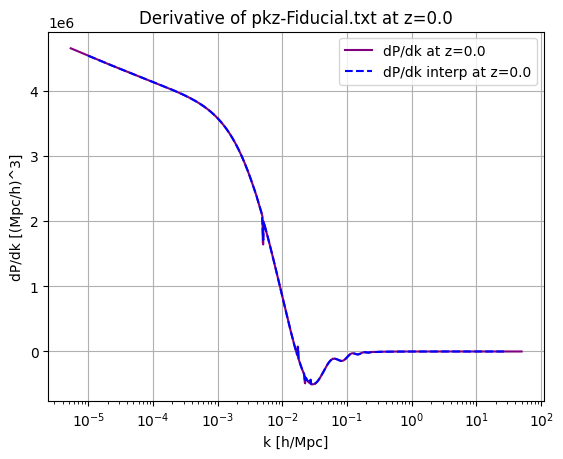

In [15]:
plt.plot(k_vals, dP_dk[0,:], '-', color = 'purple', label = 'dP/dk at z=' + str(z_vals[0]))
plt.plot(k_list, dP_dk_probe[0,:], '--', color = 'blue', label = 'dP/dk interp at z=' + str(z_vals[0]))
plt.xscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('dP/dk [(Mpc/h)^3]')#
plt.title('Derivative of ' + path + ' at z=' + str(z_vals[0]))
plt.grid()
plt.legend()
plt.show()

# Luminosity

In [16]:
z_list, Lum = int.luminosity()

In [17]:
Lumo = int.Lumo()

Interpolation of luminosity function created.


In [18]:
z_list_test = np.linspace(0, 3, 100)

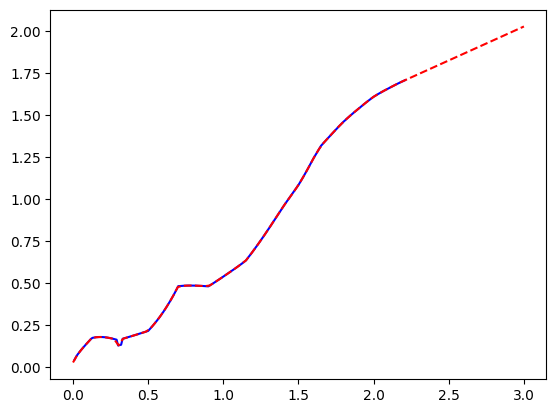

In [19]:
plt.plot(z_list, Lum, '-', color = 'blue', label = 'Data')
plt.plot(z_list_test, Lumo(z_list_test), '--', color = 'red', label = 'Our interp')
plt.show()

## Function

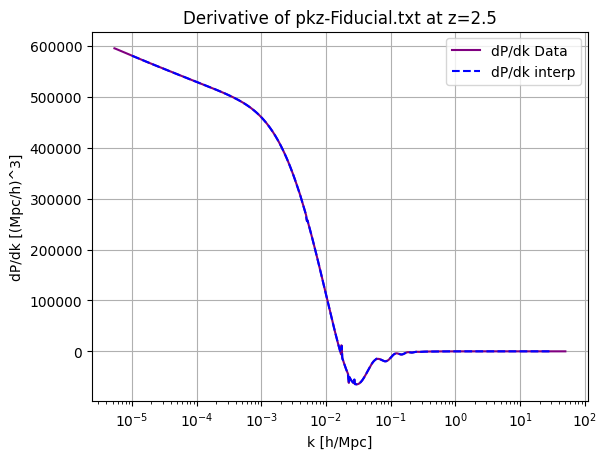

In [20]:
int.check_dPdk_interpolation('pkz-Fiducial.txt')

### Probe derivatives

In [21]:
s8_pl = int.interpolation('pkz-s8_pl_eps_1p3E-2.txt')
s8_mn = int.interpolation('pkz-s8_mn_eps_1p3E-2.txt')

Interpolation of pkz-s8_pl_eps_1p3E-2.txt done
Interpolation of pkz-s8_mn_eps_1p3E-2.txt done


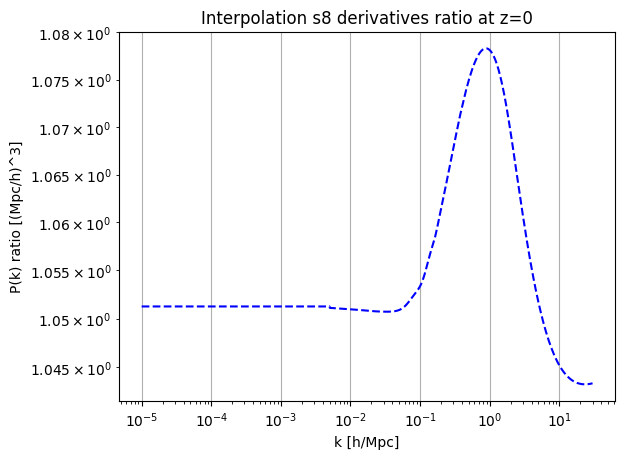

In [22]:
k_list = np.logspace(np.log10(0.00001), np.log10(30), 700) # va de 0.00001 a 30 en espacios logaritmicos

s8_pl_probe = np.exp(s8_pl(0, np.log(k_list))[0, :])
s8_mn_probe = np.exp(s8_mn(0, np.log(k_list))[0, :])
ratio_interpo = s8_pl_probe / s8_mn_probe
plt.plot(k_list, ratio_interpo, '--', color = 'blue', label = 's8 +0.013')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) ratio [(Mpc/h)^3]')#    
plt.title('Interpolation s8 derivatives ratio at z=0')   
plt.grid()
plt.show()

### Data s8

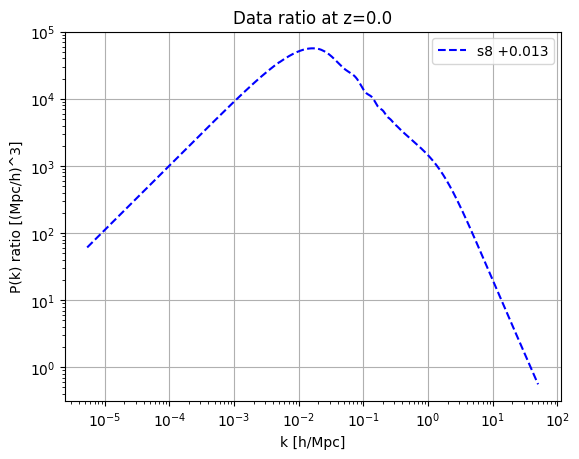

In [23]:
path = 'pkz-s8_pl_eps_1p3E-2.txt'
data = np.loadtxt(path)

z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

# Se revisa que los k sean iguales para todos los z
k_all = data[:,1]
l = len(k_vals)

#print(len(z_vals)-1)

for i in range(0, len(z_vals)-1): # va de 0 a len(z_vals)-2
    l = len(k_vals)
    A = k_all[i*l : l*(i+1)]
    B = k_all[(i+1)*l : l*(i+2)]
    if not np.array_equal(A, B):
        print("Los arrays no son iguales, se detiene el for")
        break

P_s8_pl = []

for i, z in enumerate(z_vals):
    A = P_vals[i*l : l*(i+1)]
    #print(np.flip(A))
    #print(k_vals)
    P_s8_pl.append(list(np.flip(A))) # tengo que voltear P para alinearlo luego con el orden de k_vals (de menor a mayor)

path = 'pkz-s8_mn_eps_1p3E-2.txt'
data = np.loadtxt(path)

z_vals = np.unique(data[:,0]) # devuelve z ordenados de abajo hacia arriba
k_vals = np.unique(data[:,1]) # devuelve k ordenador de abajo hacia arriba
P_vals = np.flip(data[:,3]) # devuelve P ordenado de abajo hacia arriba -> esto implica que para cada z, P esta ordenado de mayor a menor k

# Se revisa que los k sean iguales para todos los z
k_all = data[:,1]
l = len(k_vals)

#print(len(z_vals)-1)

for i in range(0, len(z_vals)-1): # va de 0 a len(z_vals)-2
    l = len(k_vals)
    A = k_all[i*l : l*(i+1)]
    B = k_all[(i+1)*l : l*(i+2)]
    if not np.array_equal(A, B):
        print("Los arrays no son iguales, se detiene el for")
        break

P_s8_mn = []

for i, z in enumerate(z_vals):
    A = P_vals[i*l : l*(i+1)]
    #print(np.flip(A))
    #print(k_vals)
    P_s8_mn.append(list(np.flip(A))) # tengo que voltear P para alinearlo luego con el orden de k_vals (de menor a mayor)

ratio_data = (np.array(P_s8_pl[0]) - np.array(P_s8_mn[0])) / (2 * 0.013 * 0.816)

plt.plot(k_vals,ratio_data , '--', color = 'blue', label = 's8 +0.013')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) ratio [(Mpc/h)^3]')#       
plt.title('Data ratio at z=' + str(z_vals[0]))
plt.grid()
plt.legend()
plt.show()


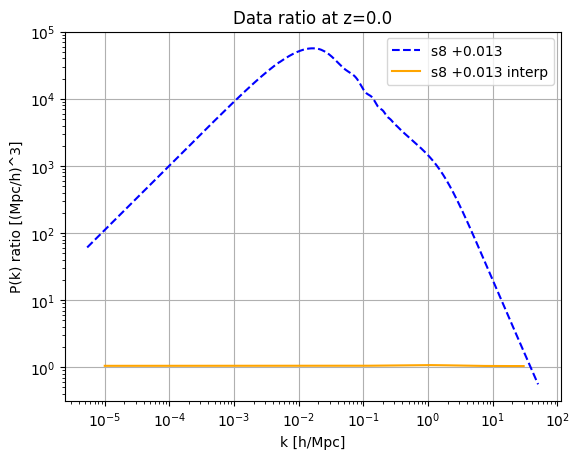

In [24]:
plt.plot(k_vals,ratio_data , '--', color = 'blue', label = 's8 +0.013')
plt.plot(k_list, ratio_interpo, '-', color = 'orange', label = 's8 +0.013 interp')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) ratio [(Mpc/h)^3]')#       
plt.title('Data ratio at z=' + str(z_vals[0]))
plt.grid()
plt.legend()
plt.show()
